# TP2 - Etapa 1: Búsqueda por Similitud de Razas de Perros

Esta notebook documenta el desarrollo, validación y análisis de un sistema de búsqueda por similitud para el reconocimiento de razas de perros.

El objetivo de esta etapa es desarrollar un sistema de recuperación de imágenes basado en similitud visual. Para lograrlo, cada imagen se representa mediante un vector de características (*embedding*) extraído por una red neuronal preentrenada, el cual se utiliza para buscar ejemplos visualmente similares dentro de una base vectorial.

El flujo principal consta de:

1. **Extracción de características:** Generación de *embeddings* de las imágenes mediante un modelo de *Deep Learning*.
2. **Búsqueda vectorial:** Recuperación de los *k* vecinos más similares a la imagen de consulta.
3. **Predicción y análisis OOD:** Estimación de la raza predominante a partir de los vecinos recuperados y análisis de imágenes *Out-of-Distribution* (OOD), utilizado para seleccionar los valores óptimos de **k** y de los umbrales de aceptación, maximizando el desempeño del sistema frente a imágenes conocidas y desconocidas.

Este enfoque aporta interpretabilidad al sistema, ya que las predicciones pueden justificarse visualmente mediante los ejemplos recuperados de la base de datos.


## Equipo
- Alumno 1 : Nicolás Mancini
- Alumno 2 : Juana Chies Doumecq

## 1. Clonar el repositorio (solo para Google Colab)

La implementación de esta etapa reutiliza componentes desarrollados previamente dentro del proyecto, incluyendo modelos entrenados, configuraciones y utilidades de visualización. Por este motivo, cuando la notebook se ejecuta en Google Colab es necesario clonar el repositorio para acceder a toda la estructura de código ubicada dentro de `src`.

La celda verifica primero si el repositorio ya fue clonado para evitar descargas redundantes y garantizar que la notebook pueda ejecutarse múltiples veces sin modificar el entorno de trabajo.

In [1]:
try:
    import google.colab
    colab = True
except ImportError:
    colab = False

if colab:
    REPO_URL = "https://github.com/nicoomancini/tuia-dog-recognition-app"

    import os
    if not os.path.exists("proyecto"):
        !git clone $REPO_URL proyecto
        %cd proyecto
    else:
        %cd proyecto

## 2. Instalar dependencias

Esta notebook utiliza bibliotecas de Deep Learning, procesamiento de imágenes, visualización y evaluación de modelos que no siempre se encuentran disponibles en entornos de ejecución temporales como Google Colab.

En un entorno local correctamente configurado mediante `requirements-etapas.txt`, esta instalación ya se encuentra resuelta y la celda puede omitirse. Mantener la instalación separada facilita la portabilidad del notebook entre distintos entornos de ejecución.

In [2]:
#!pip install -r requirements-etapas.txt

## 3. Configuración del entorno

Antes de construir el pipeline es necesario preparar el entorno de ejecución e importar todas las dependencias requeridas por las etapas de detección, clasificación, evaluación y visualización.

Además de las bibliotecas estándar de Python y PyTorch, se incorporan:

- **Ultralytics YOLO** para la detección de perros.
- **Torchvision** para la carga de arquitecturas y transformaciones de imágenes.
- **OpenCV** para el procesamiento de imágenes y manejo de recortes.
- **Scikit-Learn** para el cálculo de métricas de clasificación y matrices de confusión.
- **Difflib** para la normalización automática de etiquetas en los conjuntos OOD mediante búsqueda aproximada de nombres.

También se desactiva explícitamente el uso de `pgvector`, ya que esta etapa no requiere acceso a la base de datos vectorial utilizada en etapas producción.

Finalmente, se fijan semillas aleatorias en NumPy, Python y PyTorch para maximizar la reproducibilidad experimental. Además, se configura CuDNN en modo determinista para reducir la variabilidad entre ejecuciones cuando se utiliza GPU.

La variable `DEVICE` permite utilizar aceleración por GPU cuando está disponible, manteniendo compatibilidad automática con entornos CPU.

In [5]:
# IMPORTS
import os
import sys
import re
import random
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
from PIL import Image
import torch
import torchvision.models as models
import torchvision.transforms as T
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import ndcg_score, roc_curve, roc_auc_score
import gdown
import zipfile
import tqdm as notebook_tqdm
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
import seaborn as sns

# CONFIGURACIÓN GENERAL
#os.environ["USE_PGVECTOR"] = "False"
IMAGE_SIZE = 224

ROOT = Path.cwd()
sys.path.insert(0, str(ROOT / "src"))

from lib.config import settings
from lib.bootstrap import build_classifier

# DISPOSITIVO
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# SEMILLA
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# VERIFICACIÓN
print("dataset_path:", settings.dataset_path)
print("GPU disponible:", torch.cuda.is_available())
print("DEVICE:", DEVICE)

c:\Users\juana\OneDrive\Escritorio\TUIA\Vision por computadora\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


dataset_path: data\dataset
GPU disponible: False
DEVICE: cpu


## 4. Descarga de los datasets

**Definición de Paths**

In [6]:
DATASET_ROOT = Path('./data/dataset')

RUTA_TRAIN = DATASET_ROOT / 'train'
RUTA_VAL   = DATASET_ROOT / 'valid'
RUTA_TEST  = DATASET_ROOT / 'test'
RUTA_OOD   = DATASET_ROOT / 'ood'

### Primer Dataset: 70 Dog Breeds

In [9]:
#!python scripts/download_dataset.py

### Segundo Dataset: OOD

El dataset OOD contiene imágenes que no pertenecen a ninguna de las clases de perros del dataset principal y se utiliza para evaluar la capacidad del sistema de **rechazar imágenes que no son de razas conocidas**.

In [10]:
SUBCARPETAS_OOD = {
    "known_breeds": "1FqWUUYp39aTxqoQyRSQcYiH0157Amb_E",
    "unknown_breeds": "1G7jyvNXxzbJG-VxASetJqQR4lwv3p_Rr",
    "multiple_dogs": "1t4_aJtnb6ai_5IHb8eJuK97FvBaL8Rya",
    "non_dogs": "1XlFRwPZ3zJ2zJIBO527vNsA-VPCfTjlP",
}

for nombre, drive_id in SUBCARPETAS_OOD.items():
    ruta = RUTA_OOD / nombre

    if ruta.exists() and any(ruta.iterdir()):
        print(f"Ya existe: '{ruta}'")
        continue

    ruta.mkdir(parents=True, exist_ok=True)

    print(f"Descargando '{nombre}' desde Google Drive...")

    gdown.download_folder(
        id=drive_id,
        output=str(ruta),
        quiet=False,
        use_cookies=True,
    )

Ya existe: 'data\dataset\ood\known_breeds'
Ya existe: 'data\dataset\ood\unknown_breeds'
Ya existe: 'data\dataset\ood\multiple_dogs'
Ya existe: 'data\dataset\ood\non_dogs'


### Carga y particionado de datos 

In [19]:
ext_img = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

def normalizar(nombre: str) -> str:
    """Reemplaza espacios por '_' y elimina espacios extremos."""
    return re.sub(r"\s+", "_", nombre.strip())

def label_desde_stem(stem: str) -> str:
    """'Golden_Retriever_01' → 'Golden_Retriever'"""
    partes = stem.split("_")
    return "_".join(partes[:-1]) or stem

OOD_CONFIG = {
    "known_breeds":   {"yolo": 1, "classifier": "known"},
    "unknown_breeds": {"yolo": 1, "classifier": "unknown"},
    "multiple_dogs":  {"yolo": 1, "classifier": None},
    "non_dogs":       {"yolo": 0, "classifier": None},
}

# Construir listas de paths y etiquetas
X_train_paths, y_train_labels = [], []
X_val_paths,   y_val_labels   = [], []
X_test_paths,  y_test_labels  = [], []
X_ood_paths    = []
y_ood_label    = []
y_ood_yolo     = []
y_ood_clf      = []
y_ood_categoria = [] 

for ruta, X_paths, y_labels in [
    (RUTA_TRAIN, X_train_paths, y_train_labels),
    (RUTA_VAL,   X_val_paths,   y_val_labels),
    (RUTA_TEST,  X_test_paths,  y_test_labels),
]:
    if not ruta.exists():
        print(f"No existe: '{ruta}' — se omite.")
        continue
    for carpeta in ruta.iterdir():
        if not carpeta.is_dir():
            continue
        raza = normalizar(carpeta.name)
        for f in carpeta.iterdir():
            if f.suffix.lower() in ext_img:
                X_paths.append(f)
                y_labels.append(raza)

if not RUTA_OOD.exists():
    print(f"No existe: '{RUTA_OOD}' — se omite.")
else:
    for carpeta_nombre, config in OOD_CONFIG.items():
        carpeta = RUTA_OOD / carpeta_nombre
        if not carpeta.exists():
            print(f"OOD subcarpeta no encontrada: '{carpeta_nombre}' — se omite.")
            continue
        for f in carpeta.iterdir():
            if f.suffix.lower() not in ext_img:
                continue
            if config["classifier"] == "known":
                label = normalizar(label_desde_stem(f.stem))
            else:
                label = carpeta_nombre
            X_ood_paths.append(f)
            y_ood_label.append(label)
            y_ood_yolo.append(config["yolo"])
            y_ood_clf.append(config["classifier"])
            y_ood_categoria.append(carpeta_nombre)

print(f"Train           : {len(X_train_paths):>5} imágenes")
print(f"Valid           : {len(X_val_paths):>5} imágenes")
print(f"Test            : {len(X_test_paths):>5} imágenes")
print(f"OOD total       : {len(X_ood_paths):>5} imágenes")
print(f"  known_breeds  : {y_ood_clf.count('known'):>5} imágenes")
print(f"  unknown_breeds:  {y_ood_clf.count('unknown'):>4} imágenes")
print(f"  multiple_dogs :  {sum(l == 'multiple_dogs' for l in y_ood_label):>4} imágenes")
print(f"  non_dogs      : {sum(g == 0 for g in y_ood_yolo):>5} imágenes")

Train           :  7946 imágenes
Valid           :   700 imágenes
Test            :   700 imágenes
OOD total       :    83 imágenes
  known_breeds  :    16 imágenes
  unknown_breeds:    28 imágenes
  multiple_dogs :    15 imágenes
  non_dogs      :    24 imágenes


## 5. Análisis de ambos datasets

### Dataset 70 Dog Breeds

Este dataset es el conjunto de datos utilizado para el entrenamiento y evaluación de los modelos, compuesto por imágenes de perros pertenecientes a 70 razas diferentes. Nos proporciona una amplia diversidad de apariencias, tamaños, colores sobre los que vamos a entrenar los clasificadores para distinguir entre las distintas categorías de razas y evaluar su capacidad de generalización sobre ejemplos pertenecientes a la distribución conocida. 

#### 5.1 Distribución de clases por split

Analizamos la distribución cuantitativa de las imágenes para los tres conjuntos para buscar si hay desbalance de clases.

In [12]:
def contar_por_clase(labels):
    resultado = {}
    for label in labels:
        resultado[label] = resultado.get(label, 0) + 1
    return resultado

cnt_train = contar_por_clase(y_train_labels)
cnt_val   = contar_por_clase(y_val_labels)
cnt_test  = contar_por_clase(y_test_labels)

CLASES   = sorted(cnt_train.keys())
N_CLASES = len(CLASES)

total_tr = sum(cnt_train.values())
total_v  = sum(cnt_val.values())
total_te = sum(cnt_test.values())

print(f"  {'Clase':<22} {'Train':>6} {'Val':>5} {'Test':>5}")
print(f"  {'─'*42}")
for c in CLASES:
    print(f"  {c:<22} {cnt_train.get(c, 0):>6} {cnt_val.get(c, 0):>5} {cnt_test.get(c, 0):>5}")
print(f"  {'─'*42}")
print(f"  {'TOTAL':<22} {total_tr:>6} {total_v:>5} {total_te:>5}")
print(f"\n  Total: {total_tr + total_v + total_te:,} imágenes  |  Clases: {N_CLASES}")

  Clase                   Train   Val  Test
  ──────────────────────────────────────────
  Afghan                    105    10    10
  African_Wild_Dog          109    10    10
  Airedale                  117    10    10
  American_Hairless          65    10    10
  American_Spaniel           89    10    10
  Basenji                    99    10    10
  Basset                    159    10    10
  Beagle                    123    10    10
  Bearded_Collie             79    10    10
  Bermaise                  131    10    10
  Bichon_Frise              105    10    10
  Blenheim                  113    10    10
  Bloodhound                147    10    10
  Bluetick                  107    10    10
  Border_Collie             112    10    10
  Borzoi                    110    10    10
  Boston_Terrier             79    10    10
  Boxer                     134    10    10
  Bull_Mastiff              128    10    10
  Bull_Terrier              101    10    10
  Bulldog                   125

El análisis de la distribución del dataset muestra un comportamiento diferenciado entre los distintos splits. Tanto el conjunto de validación como el de test presentan una distribución completamente balanceada, donde cada una de las 70 razas cuenta con exactamente 10 imágenes. Esto es altamente beneficioso para la evaluación del modelo, ya que garantiza que todas las clases contribuyan de manera equitativa a las métricas, evitando sesgos derivados de desbalances en la distribución.

En contraste, el conjunto de entrenamiento presenta un claro desbalance de clases, con una variación significativa en la cantidad de imágenes por raza. Algunas clases como *Shih-Tzu*, *Labrador*, *Basset*, *Pug* y *Pomeranian* cuentan con muchas más muestras en comparación con otras como *American_Hairless*, *Newfoundland* o *Siberian_Husky*. Este desbalance puede influir directamente en el aprendizaje del modelo, favoreciendo el desempeño en las clases mayoritarias y perjudicando a las minoritarias. Por este motivo, durante el entrenamiento se consideran estrategias de mitigación como el uso de pesos de clase en la función de pérdida, técnicas de data augmentation y posibles enfoques de re-muestreo.


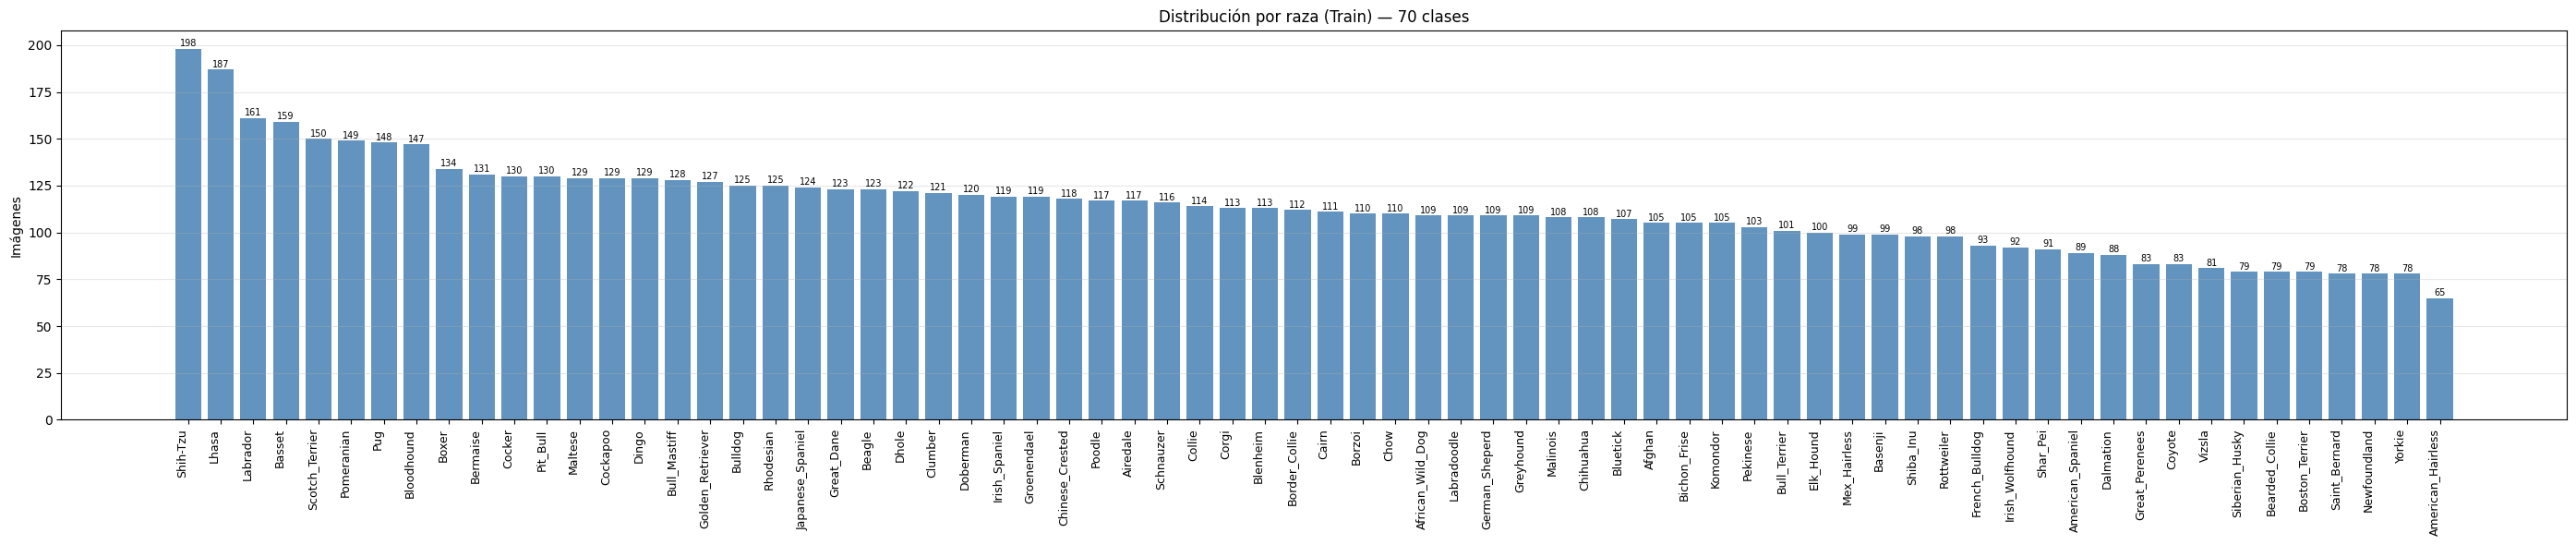

In [13]:
df_train_counts = pd.DataFrame.from_dict(cnt_train, orient="index", columns=["count"])
df_train_counts = df_train_counts.sort_values(by="count", ascending=False)

fig, ax = plt.subplots(figsize=(max(8, N_CLASES * 0.4), 6))
bars = ax.bar(df_train_counts.index, df_train_counts["count"], color="steelblue", alpha=0.85)

ax.set_xticks(range(len(df_train_counts.index)))
ax.set_xticklabels(df_train_counts.index, rotation=90, ha="right", fontsize=9)
ax.set_ylabel("Imágenes")
ax.set_title(f"Distribución por raza (Train) — {N_CLASES} clases")
ax.grid(axis="y", alpha=0.3)

for bar in bars:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, h + 0.3, str(int(h)),
            ha="center", va="bottom", fontsize=7)

plt.tight_layout()
plt.show()

El gráfico evidencia de manera clara el **desbalance de clases** presente en el conjunto de entrenamiento. Se observa una distribución heterogénea en la cantidad de imágenes por raza, donde ciertas clases como *Shih-Tzu* concentran una proporción significativamente mayor de muestras en comparación con otras como *American_Hairless*, *Newfoundland*, *Yorkie* o *Saint_Bernard*, entre otras.

Este tipo de distribución desigual es un problema frecuente en datasets de imágenes y puede influir directamente en el proceso de aprendizaje del modelo, favoreciendo el desempeño en las clases mayoritarias y reduciendo la capacidad de generalización sobre las clases minoritarias. Por este motivo, resulta fundamental considerar este factor durante el diseño del entrenamiento e incorporar estrategias de mitigación que permitan compensar el desbalance y mejorar el rendimiento global del sistema.


#### 5.2 Muestras visuales por raza

Graficamos una muestra aleatoria de imágenes para identificar la variabilidad intra-clase
(pose, iluminación, color del pelaje) y los desafíos del entorno (fondos complejos, etc.).

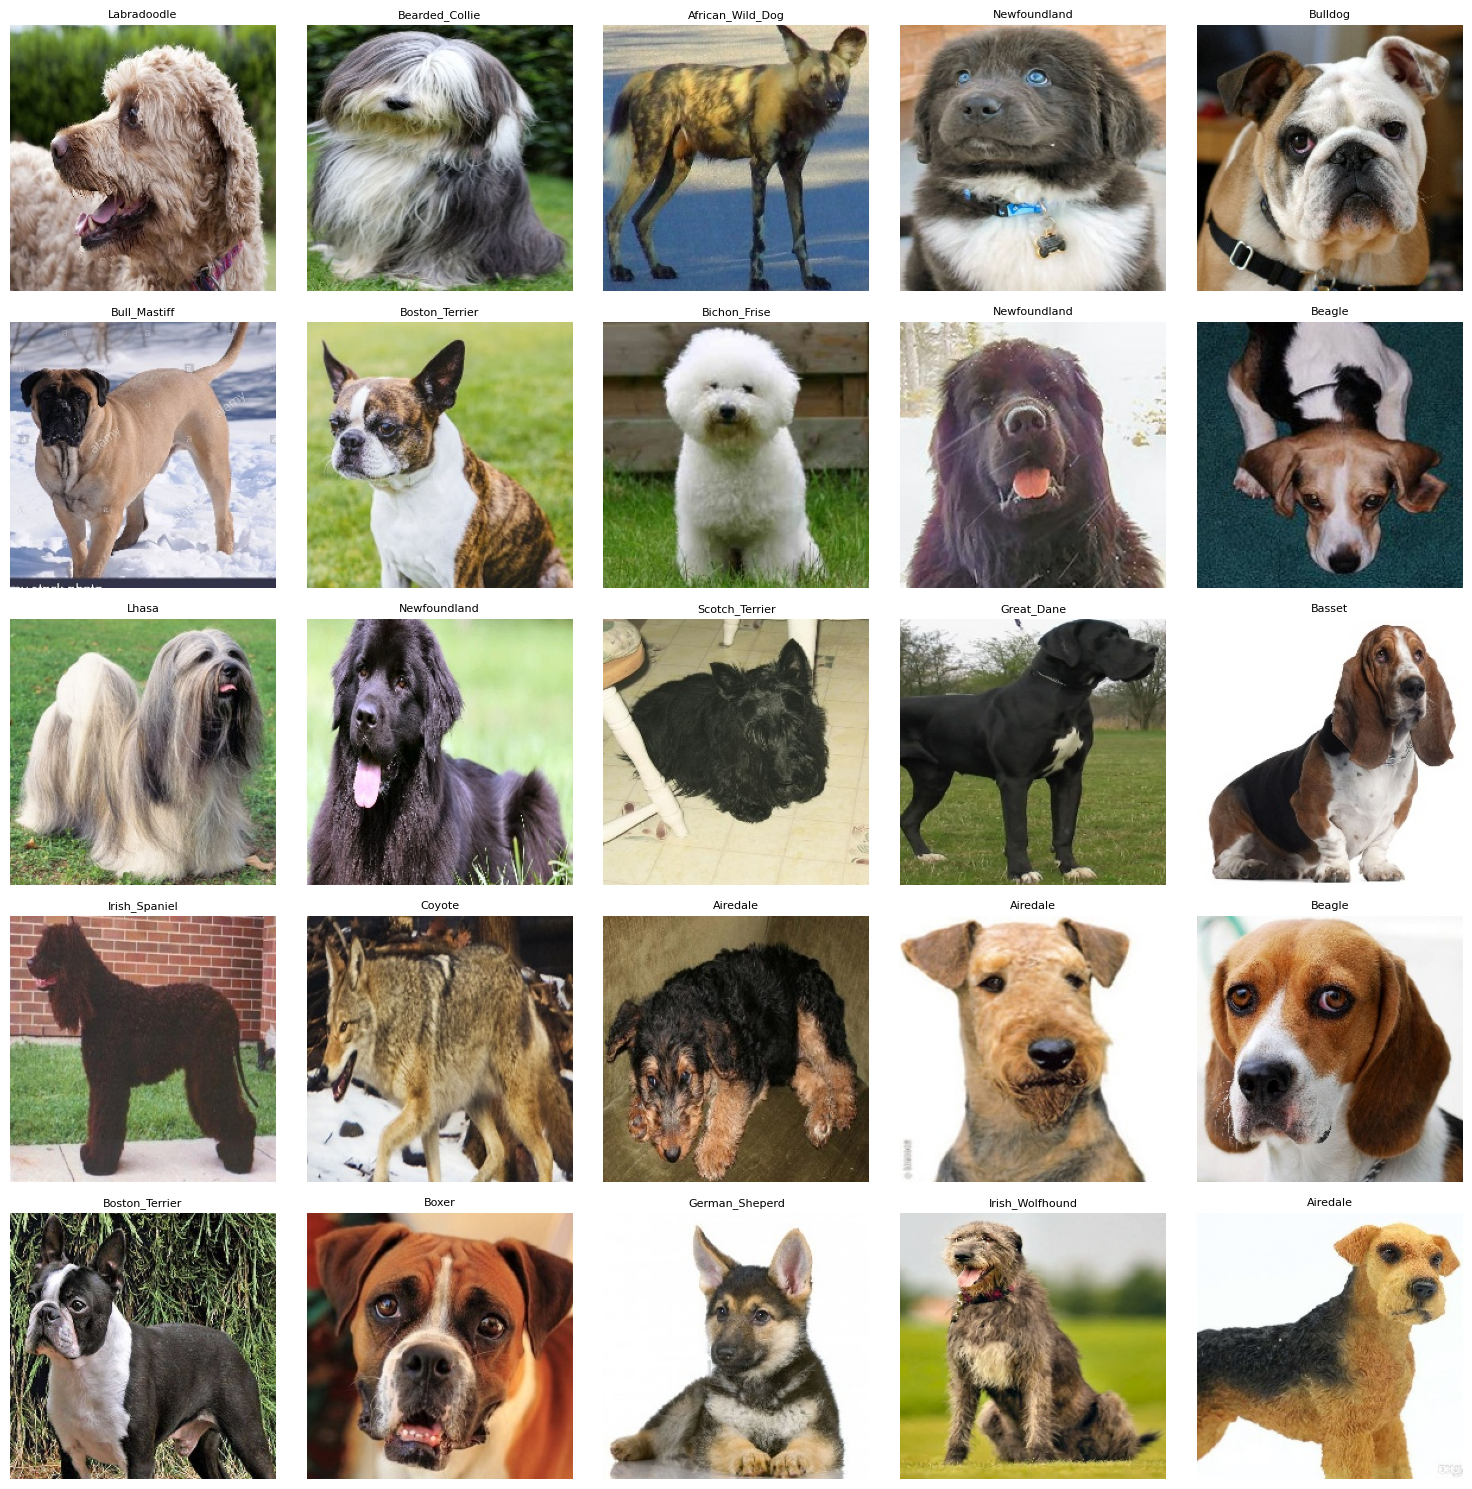

In [14]:
random.seed(SEED)
indices = random.sample(range(len(X_train_paths)), 25)

fig, axes = plt.subplots(5, 5, figsize=(15, 15))

for ax, idx in zip(axes.ravel(), indices):
    img = Image.open(X_train_paths[idx])
    ax.imshow(img)
    ax.set_title(y_train_labels[idx], fontsize=8)
    ax.axis("off")

plt.tight_layout()
plt.show()

El análisis visual del dataset revela varios factores relevantes que impactan directamente en la tarea de reconocimiento por similitud. En primer lugar, se observa una alta **variabilidad intra-clase**, donde imágenes de una misma raza presentan diferencias significativas en pose, iluminación, ángulo de captura y condiciones del entorno. Esta variabilidad obliga al modelo a aprender representaciones robustas que no dependan de características superficiales de la imagen.

En segundo lugar, muchas imágenes presentan **entornos complejos o ruidosos**, con fondos que no aportan información relevante para la clasificación. Esto introduce un desafío adicional, ya que el sistema debe ser capaz de concentrarse en el objeto de interés (el perro) y minimizar la influencia de elementos del fondo durante la extracción de características.

Finalmente, se identifica la presencia de **similitudes inter-clase**, donde distintas razas comparten características visuales muy parecidas, dificultando su discriminación. Este fenómeno es particularmente evidente en grupos de razas con morfologías cercanas, lo que incrementa la complejidad del problema de clasificación.

En conjunto, estas observaciones justifican la necesidad de utilizar modelos de *embeddings* robustos y preentrenados, capaces de capturar representaciones de alto nivel que permitan diferenciar adecuadamente entre clases similares y manejar la variabilidad inherente del dominio.


#### 5.3 Resoluciones originales

Analizamos las resoluciones originales del dataset para verificar si las imágenes ya poseen un formato estandarizado o requieren redimensión.

In [33]:
def contar_resoluciones(paths):
    counts = {}
    for path in paths:
        try:
            with Image.open(path) as im:
                counts[(im.width, im.height)] = counts.get((im.width, im.height), 0) + 1
        except Exception:
            pass
    return counts

for nombre, paths in [("Train", X_train_paths), ("Validation", X_val_paths), ("Test", X_test_paths)]:
    counts = contar_resoluciones(paths)
    unica  = len(counts) == 1
    dims   = list(counts.keys())[0] if unica else None
    print(f"  {nombre}: {'1 resolución única ' + str(dims) if unica else str(len(counts)) + ' resoluciones distintas'}")

  Train: 1 resolución única (224, 224)
  Validation: 1 resolución única (224, 224)
  Test: 1 resolución única (224, 224)


Las imágenes en el dataset ya están estandarizadas a una resolución de 224x224 píxeles, que es exactamente el valor de `IMAGE_SIZE` que definimos en la configuración general, por lo cual, no impementaremos tecnicas de prepocesamiento para cambiar la resolución de la imagenes.



### Dataset Out-of-Distribution (OOD)

Además de evaluar el rendimiento del sistema sobre datos similares a los utilizados durante el entrenamiento, resulta fundamental analizar su comportamiento frente a escenarios fuera de distribución (Out-of-Distribution, OOD). Para ello, se construyó un conjunto de imágenes que incluye perros de razas conocidas y desconocidas, escenas con múltiples perros y casos donde no hay perros presentes. 

En conjunto, estas categorías permiten construir un conjunto de evaluación OOD diverso que contempla distintos escenarios donde el sistema puede enfrentarse a entradas diferentes a las observadas durante el entrenamiento. El objetivo no es analizar cada caso de manera aislada, sino utilizar todas las imágenes OOD para medir la robustez general del pipeline y optimizar mecanismos de rechazo de consultas fuera de distribución. En particular, este conjunto será utilizado para estudiar la distribución de similitudes y determinar un umbral (threshold) que permita distinguir de forma efectiva entre consultas válidas y consultas OOD, buscando un equilibrio adecuado entre cobertura y precisión.

En cada seccion posterior iremos analizando que representa cada imagen y visualizando algunos ejemplos de ellas.

In [25]:
def mostrar_ejemplos_ood(categoria, X_ood_paths, y_ood_categoria, n=5, seed=42):
    random.seed(seed)

    indices = [i for i, c in enumerate(y_ood_categoria) if c == categoria]
    muestra = [X_ood_paths[i] for i in random.sample(indices, min(n, len(indices)))]

    fig, axes = plt.subplots(1, len(muestra), figsize=(18, 4))
    if len(muestra) == 1:
        axes = [axes]

    fig.suptitle(f"Ejemplos: {categoria}", fontsize=12, fontweight="bold")

    for ax, path in zip(axes, muestra):
        img_bgr = cv2.imread(str(path))
        ax.imshow(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB))
        ax.axis("off")

    plt.tight_layout()
    plt.show()

#### Caso 1: Razas Conocidas (unknown_breeds)

Esta subcarpeta contiene imágenes de perros cuyas razas forman parte del conjunto de entrenamiento del clasificador. Estos ejemplos permiten verificar que el sistema mantiene un buen desempeño sobre casos conocidos incluso cuando las imágenes provienen de una distribución diferente a la utilizada para entrenar.

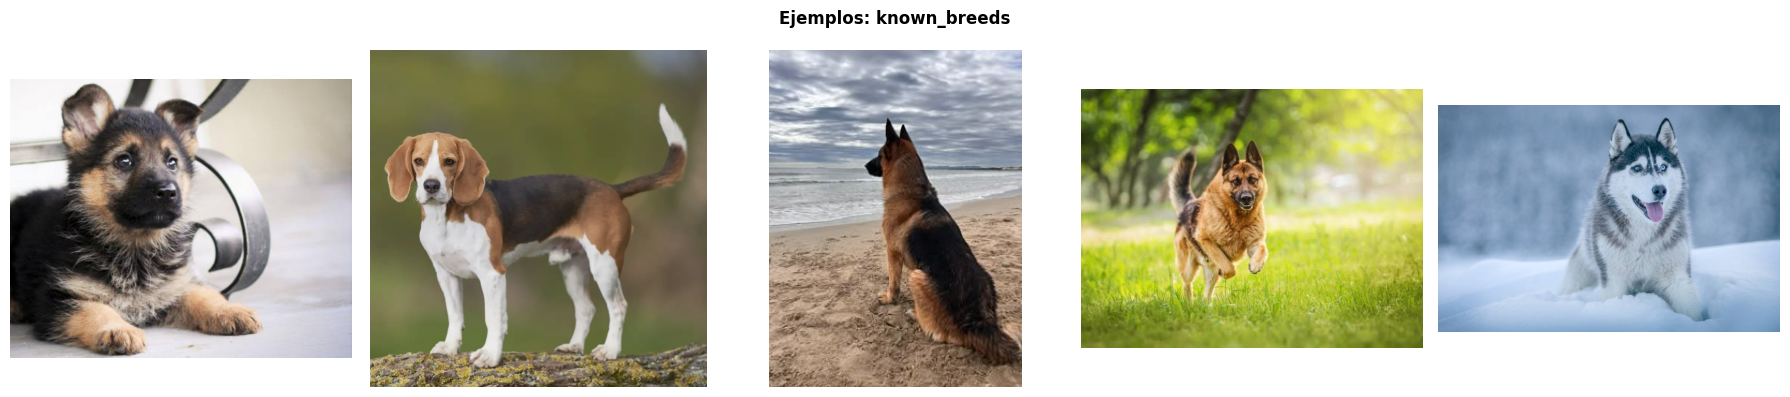

In [27]:
mostrar_ejemplos_ood("known_breeds", X_ood_paths, y_ood_categoria)


#### Caso 2: Razas Desconocidas (unknown_breeds) 

Esta subcarpeta incluye imágenes de perros pertenecientes a razas que no fueron vistas durante el entrenamiento. Este conjunto es relevante para evaluar la capacidad del sistema de reconocer sus limitaciones y evitar clasificaciones erróneas sobre categorías desconocidas.

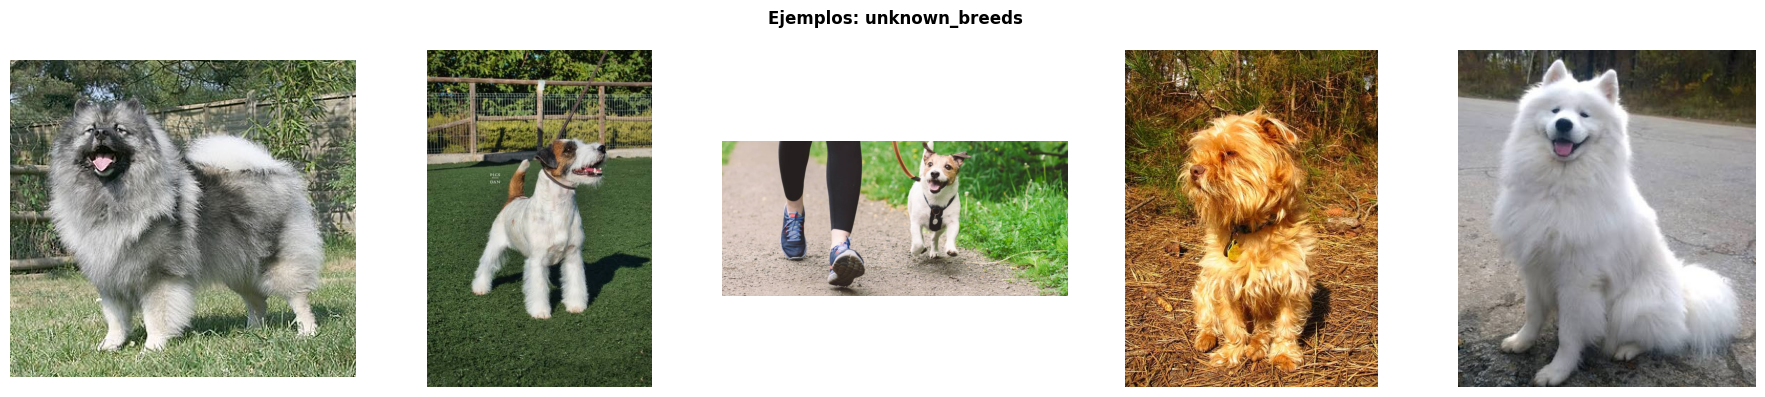

In [28]:
mostrar_ejemplos_ood("unknown_breeds", X_ood_paths, y_ood_categoria)


#### Caso 3: Múltiples Perros (multiple_dogs)

Esta subcarpeta contiene imágenes donde aparecen dos o más perros en una misma escena. Estos casos permiten analizar el comportamiento del pipeline en escenarios más complejos y cercanos a situaciones reales, donde múltiples objetos de interés pueden coexistir en una imagen.

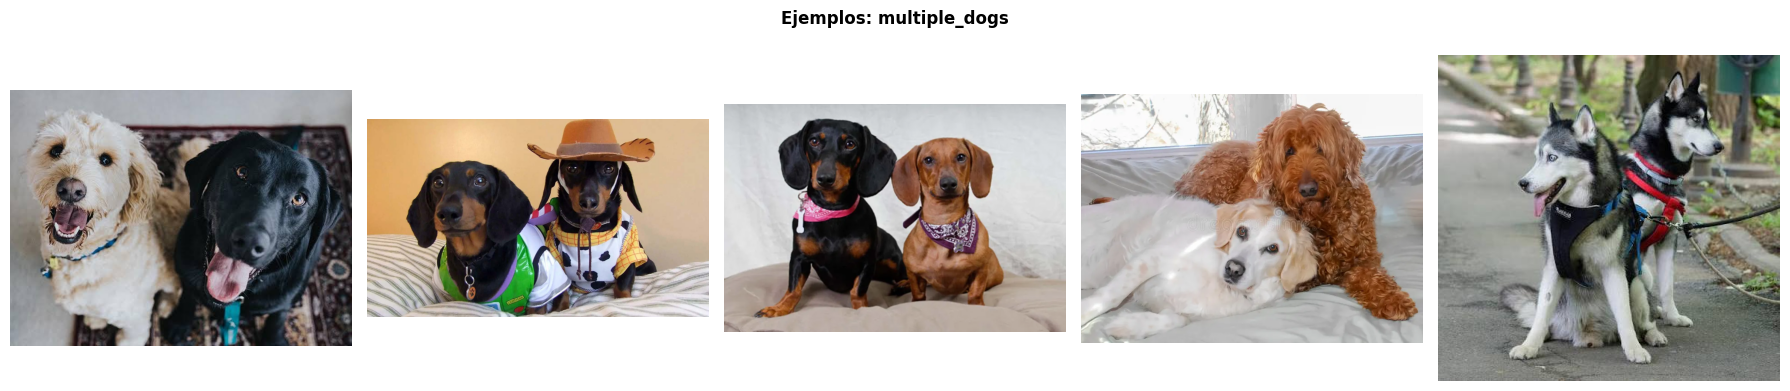

In [29]:
mostrar_ejemplos_ood("multiple_dogs", X_ood_paths, y_ood_categoria)

#### Caso 4: Ausencia de Perros (non_dogs)

Esta subcarpeta está compuesta por imágenes que no contienen perros, incluyendo de otros animales. Este conjunto resulta esencial para medir la tasa de falsos positivos y verificar que el sistema no identifica perros donde no los hay.

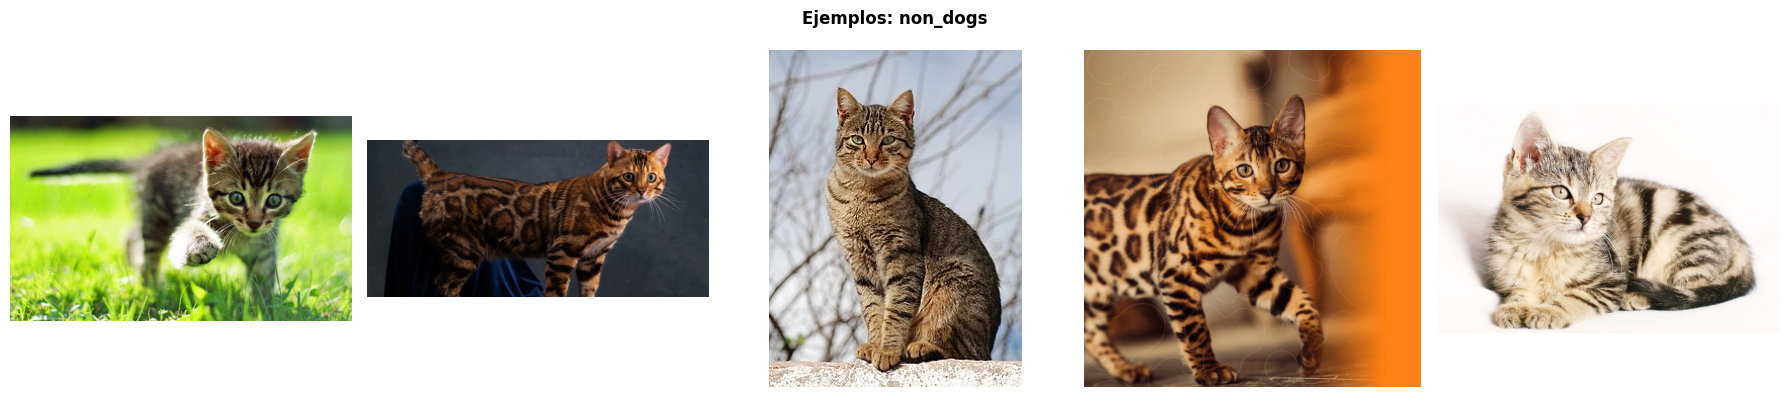

In [30]:
mostrar_ejemplos_ood("non_dogs", X_ood_paths, y_ood_categoria)


#### Resoluciones originales

In [34]:
counts = contar_resoluciones(X_ood_paths)
unica  = len(counts) == 1
dims   = list(counts.keys())[0] if unica else None
print(f"  OOD: {'1 resolución única ' + str(dims) if unica else str(len(counts)) + ' resoluciones distintas'}")

  OOD: 72 resoluciones distintas


El conjunto OOD presenta 72 resoluciones distintas, incorporando una amplia variedad de tamaños y relaciones de aspecto. Esta heterogeneidad resulta útil para evaluar la robustez del sistema frente a imágenes obtenidas en diferentes condiciones. No obstante, estas diferencias se normalizan durante el preprocesamiento mediante la etapa de resize incluida en las transformaciones aplicadas a las imágenes, garantizando que todas las entradas sean procesadas con dimensiones consistentes por el modelo.

## 6. Carga de los modelos 

En esta etapa, se preparan **4 modelos pre-entrenados** que se utilizarán como generadores de embeddings para evaluar su rendimiento en la tarea de similitud de razas de perros:

*   **ResNet18:** Una red convolucional residual más ligera, conocida por su eficiencia y buen rendimiento para su tamaño.

*   **ResNet50:** Una versión más profunda de ResNet, con 50 capas. Ofrece mayor capacidad de aprendizaje y, generalmente, mejor rendimiento que ResNet18 a costa de más recursos computacionales.

*   **EfficientNet-B0:** Pertenece a una familia de modelos que escalan eficientemente la profundidad, el ancho y la resolución de la red. B0 es la versión base, conocida por su buen equilibrio entre precisión y eficiencia.

*   **ConvNeXt-Tiny:** Un modelo más reciente que busca modernizar las arquitecturas convolucionales, inspirándose en las redes Transformer. Ofrece un rendimiento competitivo con un diseño puramente convolucional.

Todos estos modelos fueron entrenados con el mismo dataset, por lo cual comparten la misma normalización, pero generan embeddings de dimensionalidades muy diferentes:
*   **ResNet18:** `embedding_dim=512`

*   **ResNet50:** `embedding_dim=2048`

*   **EfficientNet-B0:** `embedding_dim=1280`

*   **ConvNeXt-Tiny:** `embedding_dim=768`

In [34]:
resnet18 = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
resnet18.fc = torch.nn.Identity()
resnet18 = resnet18.to(DEVICE).eval()

resnet50 = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
resnet50.fc = torch.nn.Identity()
resnet50 = resnet50.to(DEVICE).eval()

efficientnet_b0 = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)
efficientnet_b0.classifier = torch.nn.Identity()
efficientnet_b0 = efficientnet_b0.to(DEVICE).eval()

convnext_tiny = models.convnext_tiny(weights=models.ConvNeXt_Tiny_Weights.DEFAULT)
convnext_tiny.classifier = torch.nn.Identity()
convnext_tiny = convnext_tiny.to(DEVICE).eval()

MODELOS = {"resnet18": resnet18, "resnet50": resnet50, "efficientnet_b0": efficientnet_b0, "convnext_tiny":   convnext_tiny,}

print("Modelos cargados:")
for name, m in MODELOS.items():
    with torch.no_grad():
        dummy = torch.zeros(1, 3, IMAGE_SIZE, IMAGE_SIZE).to(DEVICE)
        dim = m(dummy).squeeze().shape[-1]
    print(f"{name:<20}  embedding_dim={dim}")

Modelos cargados:
resnet18              embedding_dim=512
resnet50              embedding_dim=2048
efficientnet_b0       embedding_dim=1280
convnext_tiny         embedding_dim=768


In [35]:
# Construcción de diccionarios de entrada 
train_entries = [{
    "path": p,
    "breed": b
} for p, b in zip(X_train_paths, y_train_labels)]

val_entries = [{
    "path": p,
    "breed": b
} for p, b in zip(X_val_paths, y_val_labels)]

test_entries = [{
    "path": p,
    "breed": b
} for p, b in zip(X_test_paths, y_test_labels)]

## 7. Definición de las funciones necesarias en producción

En esta sección se definen las funciones clave que encapsulan la lógica para transformar imágenes, extraer sus embeddings y buscar las más similares en una base de datos. 

In [36]:
transform_imagenet = T.Compose([
    T.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

def extract_embedding(image, model) -> list:
    """Extrae el embedding de una imagen usando el modelo dado sin normalización."""
    if not isinstance(image, Image.Image):
        image = Image.open(image).convert("RGB")
    else:
        image = image.convert("RGB")

    tensor = transform_imagenet(image).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        emb = model(tensor).squeeze().flatten().cpu().numpy()
    
    return emb.tolist()

In [37]:
def search_similar_images(embedding: list, image_entries: list, embeddings_ref: list, similarity_fn, top_k: int = 10) -> list:
    """Busca las top_k imágenes más similares al embedding dado."""
    q = np.array(embedding)
    scores = []
    for entry, ref_emb in zip(image_entries, embeddings_ref):
        sim = similarity_fn(q, ref_emb)
        scores.append({"path": str(entry["path"]), "breed": entry["breed"], "similarity": sim})
    scores.sort(key=lambda x: x["similarity"], reverse=True)
    return scores[:top_k]

In [38]:
def predict_breed_from_neighbors(results: list) -> str:
    """Predice la raza por voto mayoritario ponderado por similitud."""
    votes = {}
    for item in results:
        breed = item["breed"]
        votes[breed] = votes.get(breed, 0) + item["similarity"]
    return max(votes, key=votes.get)

## 8. Definición de funciones adicionales

A partir de las funciones `cosine_similarity` y `euclidean_similarity` obtenemos métricas para cuantificar la "cercanía" entre dos vectores de embeddings. 

* La **similitud coseno** mide el ángulo entre dos vectores, ignorando su magnitud. 

* La **similitud euclidiana** se basa en la distancia euclidiana entre los puntos en el espacio vectorial. En este contexto, se transforma la distancia euclidiana a una escala de similitud (0 a 1) mediante la fórmula `1 / (1 + distancia)`, donde un valor más alto indica mayor similitud. 

In [39]:
def cosine_similarity(a: np.ndarray, b: np.ndarray) -> float:
    """Similitud coseno entre dos vectores. Rango [-1, 1]."""
    denom = np.linalg.norm(a) * np.linalg.norm(b)
    if denom == 0:
        return 0.0
    return float(np.dot(a, b) / denom)

def euclidean_similarity(a: np.ndarray, b: np.ndarray) -> float:
    """Similitud basada en distancia euclidiana. Rango (0, 1]."""
    return float(1 / (1 + np.linalg.norm(a - b)))

A partir de la función `evaluar_modelo` podemos evaluar el rendimiento de nuestro sistema de búsqueda por similitud, al calcular las métricas **NDCG@10** y **Accuracy**. 

* **NDCG (Normalized Discounted Cumulative Gain)** es una métrica de ranking que evalúa la calidad de un conjunto ordenado de resultados, dando más peso a los elementos relevantes que aparecen en posiciones más altas. Esto es crucial para la búsqueda, donde el orden de los resultados es tan importante como su presencia. 

* **El Accuracy** mide la proporción de aciertos en la predicción de la raza, utilizando la votación mayoritaria ponderada de `predict_breed_from_neighbors`. Al considerar `query_entries` y `index_entries`, esta función simula cómo el modelo se desempeñaría en la práctica al buscar imágenes similares y predecir sus razas.

In [40]:
def evaluar_modelo(query_entries, query_embs, index_entries, index_embs, similarity_fn, top_k=10):
    ndcg_scores, aciertos = [], []

    for query_entry, query_emb in zip(query_entries, query_embs):
        results = search_similar_images(query_emb, index_entries, index_embs, similarity_fn, top_k=top_k)

        relevances = [1 if r["breed"] == query_entry["breed"] else 0 for r in results]
        if sum(relevances) > 0:
            ndcg_scores.append(ndcg_score([relevances], [[r["similarity"] for r in results]]))

        pred = predict_breed_from_neighbors(results)
        aciertos.append(int(pred == query_entry["breed"]))

    return {"ndcg@10":  np.mean(ndcg_scores) if ndcg_scores else 0.0, "accuracy": np.mean(aciertos)}

La función `evaluar_con_threshold` extiende la evaluación de modelos para incluir un mecanismo de **rechazo de consultas Out-Of-Distribution (OOD)** o de baja confianza, con el objetivo de simular cómo se comportaría el sistema en un escenario real donde no todas las consultas pueden ser clasificadas con alta seguridad.

In [41]:
def evaluar_con_threshold(image_entries, embeddings, similarity_fn, top_k, threshold):
    total = len(image_entries)
    correctas, aceptadas = 0, 0

    for query_entry, query_emb in zip(image_entries, embeddings):
        results = search_similar_images(query_emb, image_entries, embeddings, similarity_fn, top_k=top_k + 1)
        results = [r for r in results if r["path"] != str(query_entry["path"])][:top_k]

        if not results or results[0]["similarity"] < threshold:
            continue  

        aceptadas += 1
        pred = predict_breed_from_neighbors(results)
        if pred == query_entry["breed"]:
            correctas += 1

    cobertura = aceptadas / total
    acc_sobre_aceptadas = correctas / aceptadas if aceptadas > 0 else 0.0

    return {
        "accuracy_global":          correctas / total,        
        "accuracy_sobre_aceptadas": acc_sobre_aceptadas,      
        "cobertura":                cobertura,                 
        "aceptadas":                aceptadas,
        "rechazadas":               total - aceptadas,
    }

La función `graficar_tsne` se utiliza para visualizar los embeddings de alta dimensionalidad en un espacio bidimensional con el entender cómo el modelo agrupa las diferentes razas en el espacio de características.

In [42]:
def graficar_tsne(X_embeddings, y_breeds):
    "Grafica una reducción de dimensionalidad t-SNE de los embeddings."
    # PCA a 50 dimensiones 
    X = np.array(X_embeddings)
    n_components_pca = min(50, X.shape[1])
    pca = PCA(n_components=n_components_pca, random_state=42)
    X_pca = pca.fit_transform(X)
    
    # Aplicamos t-SNE para bajar a 2D
    tsne = TSNE(n_components=2, perplexity=30, random_state=42, init='pca', learning_rate='auto')
    X_tsne = tsne.fit_transform(X_pca)
    df = pd.DataFrame({'Dim 1': X_tsne[:, 0], 'Dim 2': X_tsne[:, 1], 'Raza': y_breeds})
    
    # Gráfico
    plt.figure(figsize=(16, 8))
    sns.scatterplot(data=df, x='Dim 1', y='Dim 2', hue='Raza', palette=sns.color_palette("husl", len(df['Raza'].unique())), legend=False, alpha=0.6, s=30)
    
    # Etiquetar los centroides
    for raza in df['Raza'].unique():
        x_mean = df[df['Raza'] == raza]['Dim 1'].mean()
        y_mean = df[df['Raza'] == raza]['Dim 2'].mean()
        plt.text(x_mean, y_mean, raza, fontsize=8, ha='center', va='center', bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', boxstyle='round,pad=0.2'))
    
    plt.title('Visualización de Embeddings (t-SNE) - 70 Razas de Perros', fontsize=16)
    plt.xlabel('Dimensión 1 (t-SNE)', fontsize=12)
    plt.ylabel('Dimensión 2 (t-SNE)', fontsize=12)
    plt.tight_layout()
    plt.show()

La función `graficar_k` está diseñada para ayudar en la **optimización del parámetro `K`**, que representa el número de vecinos más cercanos a considerar en la búsqueda por similitud. Al buscar imágenes similares, `K` define cuántos de esos vecinos se utilizan para, por ejemplo, predecir la raza o calcular métricas de ranking.

In [43]:
def graficar_k(k_values, acc_scores, ndcg_scores):
    "Genera dos gráficos lado a lado para evaluar el K óptimo basándose en Accuracy (clasificación) y NDCG (ranking)."
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))
    
    # Gráfico 1: Accuracy 
    best_k_acc = k_values[np.argmax(acc_scores)]
    best_acc = np.max(acc_scores)
    
    ax1.plot(k_values, acc_scores, marker='o', color='royalblue', linewidth=2)
    ax1.axvline(x=best_k_acc, color='red', linestyle='--', alpha=0.7, label=f'K Óptimo = {best_k_acc}\n(Acc: {best_acc:.4f})')
    ax1.scatter([best_k_acc], [best_acc], color='red', s=100, zorder=5)
    
    ax1.set_title('Optimización de K - Accuracy (Clasificación)')
    ax1.set_xlabel('Número de Vecinos (K)')
    ax1.set_ylabel('Accuracy')
    ax1.set_xticks(k_values)
    ax1.grid(True, linestyle='--', alpha=0.6)
    ax1.legend()

    # Gráfico 2: NDCG 
    best_k_ndcg = k_values[np.argmax(ndcg_scores)]
    best_ndcg = np.max(ndcg_scores)
    
    ax2.plot(k_values, ndcg_scores, marker='s', color='darkorange', linewidth=2)
    ax2.axvline(x=best_k_ndcg, color='red', linestyle='--', alpha=0.7, label=f'K Óptimo = {best_k_ndcg}\n(NDCG: {best_ndcg:.4f})')
    ax2.scatter([best_k_ndcg], [best_ndcg], color='red', s=100, zorder=5)
    
    ax2.set_title('Optimización de K - NDCG (Ranking)')
    ax2.set_xlabel('Número de Vecinos (K)')
    ax2.set_ylabel('NDCG Score')
    ax2.set_xticks(k_values)
    ax2.grid(True, linestyle='--', alpha=0.6)
    ax2.legend()

    plt.tight_layout()
    plt.show()

La función `visualizar_top_k` es una herramienta de diagnóstico para inspeccionar visualmente los resultados de la búsqueda por similitud para una imagen de consulta específica. 

In [66]:
def visualizar_top_k_real(idx_consulta, entries_consulta, embs_consulta, entries_indice, embs_indice, similarity_fn, k=10):
    """
    Visualiza la imagen de consulta, sus vecinos reales mediante tu pipeline
    y la predicción resultante.
    """

    emb_query = embs_consulta[idx_consulta]
    top_results = search_similar_images(emb_query, entries_indice, embs_indice, similarity_fn, top_k=k)
    prediccion = predict_breed_from_neighbors(top_results)
    
    # Graficar
    fig, axes = plt.subplots(1, k + 1, figsize=(18, 4))
    
    # Imagen de consulta
    img_query = Image.open(entries_consulta[idx_consulta]["path"])
    axes[0].imshow(img_query)
    axes[0].set_title(f"Consulta\nPred: {prediccion}")
    axes[0].axis('off')
    
    # Resultados
    for i, res in enumerate(top_results):
        img_res = Image.open(res["path"])
        axes[i+1].imshow(img_res)
        score = res["similarity"]
        breed = res["breed"]
        axes[i+1].set_title(f"Rank {i+1}\n{breed}\n{score:.3f}", fontsize=9)
        axes[i+1].axis('off')
        
    plt.tight_layout()
    plt.show()

## 9. Comparación de modelos y selección del mejor modelo

Esta sección es crucial para seleccionar el mejor extractor de *embeddings* y la métrica de similitud para la tarea, por lo cual se evaluarán todas las combinaciones de modelos (`ResNet18`, `ResNet50`, `EfficientNet-B0`, `ConvNeXt-Tiny`) y métricas de similitud (`Coseno`, `Euclidiana`).

In [45]:
METRICAS = {"coseno": cosine_similarity, "L2": euclidean_similarity,}

# Extraer embeddigns con cada modelo y métrica
resultados = {}
emb_cache = {}

for model_name, model in MODELOS.items():
    print(f"Calculando embeddings para: {model_name}")
    val_embs = [np.array(extract_embedding(e["path"], model)) for e in val_entries]
    test_embs = [np.array(extract_embedding(e["path"], model)) for e in test_entries]
    
    emb_cache[model_name] = {"val": val_embs, "test": test_embs}

# Evaluar modelos usando el set de Test como índice
for model_name in MODELOS.keys():
    print(f"Evaluando modelo: {model_name}")
    for metrica_nombre, metrica_fn in METRICAS.items():
        key = f"{model_name}_{metrica_nombre}"
        
        # Usar Test como índice y Val como query 
        metricas = evaluar_modelo(val_entries, emb_cache[model_name]["val"], 
                                  test_entries, emb_cache[model_name]["test"], 
                                  metrica_fn, top_k=10)
        
        resultados[key] = metricas
        print(f"  {key}: NDCG@10={metricas['ndcg@10']:.4f}")

Calculando embeddings para: resnet18


Calculando embeddings para: resnet50
Calculando embeddings para: efficientnet_b0
Calculando embeddings para: convnext_tiny
Evaluando modelo: resnet18
  resnet18_coseno: NDCG@10=0.9134
  resnet18_L2: NDCG@10=0.9088
Evaluando modelo: resnet50
  resnet50_coseno: NDCG@10=0.9571
  resnet50_L2: NDCG@10=0.9593
Evaluando modelo: efficientnet_b0
  efficientnet_b0_coseno: NDCG@10=0.9422
  efficientnet_b0_L2: NDCG@10=0.9379
Evaluando modelo: convnext_tiny
  convnext_tiny_coseno: NDCG@10=0.9632
  convnext_tiny_L2: NDCG@10=0.9646


A partir de la evaluación inicial puede observarse que todos los modelos alcanzan valores elevados de NDCG@10, superiores a 0.90, lo que indica que, independientemente de la arquitectura utilizada, los embeddings pre-entrenados son capaces de recuperar imágenes semánticamente similares con un alto grado de relevancia.

No obstante, se aprecian diferencias entre las arquitecturas evaluadas. Los modelos más recientes y de mayor capacidad representacional (como ConvNeXt Tiny y ResNet50) obtienen valores de NDCG@10 superiores a los alcanzados por EfficientNet-B0 y, especialmente, por ResNet18. Una posible explicación es que estas arquitecturas generan representaciones de mayor calidad, capaces de capturar características visuales más discriminativas entre razas con apariencias similares.

Por otro lado, las diferencias entre las métricas de distancia Coseno y L2 son reducidas en todos los casos. Esto sugiere que los embeddings generados presentan una estructura suficientemente robusta como para que el criterio de similitud empleado tenga una influencia limitada sobre el rendimiento global. Sin embargo, se observan pequeñas variaciones según la arquitectura, lo que justifica evaluar ambas alternativas antes de seleccionar la configuración definitiva.


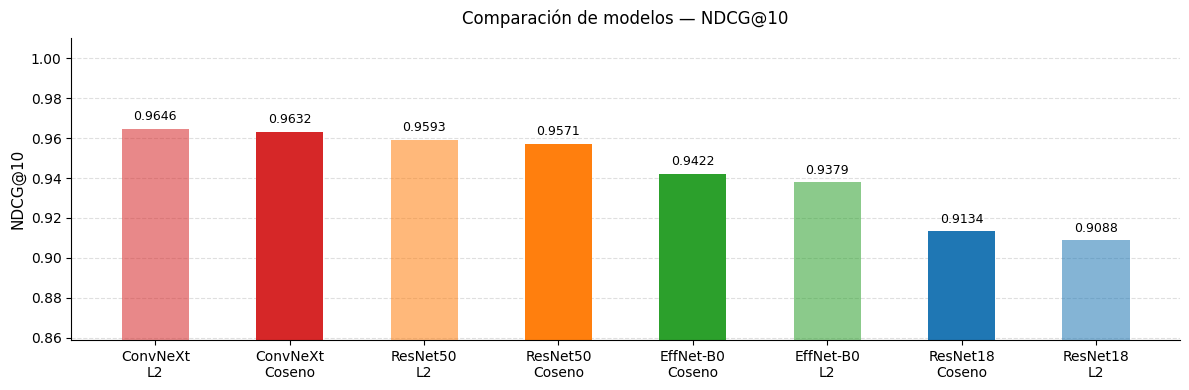

Modelo elegido  : convnext_tiny


In [46]:
# Gráfico comparativo
etiquetas = {
    "resnet18_coseno":        "ResNet18\nCoseno",
    "resnet18_L2":            "ResNet18\nL2",
    "resnet50_coseno":        "ResNet50\nCoseno",
    "resnet50_L2":            "ResNet50\nL2",
    "efficientnet_b0_coseno": "EffNet-B0\nCoseno",
    "efficientnet_b0_L2":     "EffNet-B0\nL2",
    "convnext_tiny_coseno":   "ConvNeXt\nCoseno",
    "convnext_tiny_L2":       "ConvNeXt\nL2"}

colores_base = {"resnet18": "#1f77b4", "resnet50": "#ff7f0e", "efficientnet_b0": "#2ca02c", "convnext_tiny": "#d62728",}

fig, ax = plt.subplots(figsize=(12, 4))

modelos_sorted = sorted(resultados.items(), key=lambda x: x[1]["ndcg@10"], reverse=True)
nombres = [etiquetas[m] for m, v in modelos_sorted]
scores  = [v["ndcg@10"] for m, v in modelos_sorted]
colores = [colores_base[next(k for k in colores_base if m.startswith(k))] for m, v in modelos_sorted]
alphas  = [1.0 if "coseno" in m else 0.55 for m, v in modelos_sorted]

bars = ax.bar(nombres, scores, color=colores, width=0.5)
for bar, alpha in zip(bars, alphas):
    bar.set_alpha(alpha)

ax.bar_label(bars, fmt="%.4f", padding=4, fontsize=9)
ax.set_ylim(max(0, min(scores) - 0.05), 1.01)
ax.set_ylabel("NDCG@10", fontsize=11)
ax.set_title("Comparación de modelos — NDCG@10", fontsize=12, pad=10)
ax.spines[["top", "right"]].set_visible(False)
ax.yaxis.grid(True, linestyle="--", alpha=0.4)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

# Elegir el mejor modelo según NDCG@10
mejor_key = max(resultados, key=lambda k: resultados[k]["ndcg@10"])
for model_name in MODELOS:
    if mejor_key.startswith(model_name):
        MODELO_ELEGIDO = model_name
        break

# Selección del mejor modelo
model_elegido  = MODELOS[MODELO_ELEGIDO]
METRICA_FN = euclidean_similarity if mejor_key.endswith("L2") else cosine_similarity
print(f"Modelo elegido  : {MODELO_ELEGIDO}")

# Descarga del mejor modelo
MODELS_DIR = ROOT / "models"
MODELS_DIR.mkdir(exist_ok=True)
save_path = MODELS_DIR / "baseline.pth"
torch.save(model_elegido.state_dict(), save_path)

A partir del gráfico comparativo de NDCG@10 podemos ver que el modelo ConvNeXt Tiny alcanza el mejor desempeño con ambas métricas, obteniendo un NDCG@10 de 0.9646 con distancia L2 y 0.9632 con distancia Coseno. Muy cerca se ubica ResNet50, cuyos valores (0.9593 y 0.9571) evidencian también una excelente capacidad para generar embeddings discriminativos. En un segundo nivel aparece EfficientNet-B0, mientras que ResNet18 presenta el rendimiento más bajo del conjunto evaluado.

En cuanto a la comparación entre las métricas de distancia, puede observarse que las diferencias son mínimas para todas las arquitecturas (inferiores a 0.005 puntos de NDCG@10). En ConvNeXt Tiny, ResNet50 y ResNet18 la distancia Euclídea obtiene una ligera ventaja, mientras que EfficientNet-B0 presenta un comportamiento marginalmente mejor utilizando similitud por Coseno. Estas diferencias, aunque pequeñas, indican que la elección de la métrica puede depender de la distribución de los embeddings producidos por cada backbone.

En conjunto, los resultados evidencian que la arquitectura utilizada tiene un impacto considerablemente mayor sobre la calidad del ranking que la métrica de similitud empleada. Las diferencias entre modelos alcanzan aproximadamente seis puntos porcentuales de NDCG@10, mientras que el efecto de cambiar entre Coseno y L2 resulta prácticamente no se nota. Esto sugiere que la selección del backbone constituye el principal factor para maximizar el rendimiento del sistema de recuperación.

Por esta razón, se seleccionó ConvNeXt Tiny como el modelo base para las siguientes etapas del trabajo, utilizando la distancia Euclídea (L2) como métrica de similitud. Esta configuración obtuvo el mayor valor de NDCG@10 (0.9646), evidenciando la mejor capacidad para recuperar imágenes relevantes y ordenarlas correctamente según su similitud visual. 

In [47]:
# Elegir mejor modelo
if MODELO_ELEGIDO in emb_cache:
    val_embs_final = emb_cache[MODELO_ELEGIDO]["val"]
    train_embs_final = emb_cache[MODELO_ELEGIDO].get("train", [np.array(extract_embedding(e["path"], model_elegido)) for e in train_entries])
else:
    val_embs_final = [np.array(extract_embedding(e["path"], model_elegido)) for e in val_entries]
    train_embs_final = [np.array(extract_embedding(e["path"], model_elegido)) for e in train_entries]

val_embs = val_embs_final
train_embs = train_embs_final

## 10. Cálculo del mejor threshold / k (Vecinos)

Una vez seleccionado el backbone y la métrica de similitud, el siguiente paso consiste en optimizar los hiperparámetros que determinan el comportamiento del sistema durante la inferencia. En particular, se ajustan dos parámetros fundamentales: el umbral de aceptación (threshold) y el número de vecinos (K) utilizado para la predicción de la raza.

El threshold permite distinguir entre consultas que pertenecen a la distribución conocida (in-distribution) y aquellas que corresponden a imágenes fuera de distribución (Out-of-Distribution, OOD). Su objetivo es evitar que el sistema asigne una raza a imágenes que no representan perros, contienen múltiples perros o pertenecen a razas no contempladas durante el entrenamiento.

Por su parte, el parámetro K controla la cantidad de vecinos más cercanos considerados durante la clasificación por voto mayoritario ponderado. Su elección implica un compromiso entre robustez y precisión: valores pequeños priorizan la similitud local, mientras que valores elevados incorporan mayor contexto a costa de aumentar la influencia de vecinos potencialmente menos relevantes.

Ambos hiperparámetros se optimizan sobre el conjunto de validación, preservando el conjunto de test exclusivamente para la evaluación final y evitando así cualquier sesgo durante el proceso de selección.

### Obtención del umbral de aceptación (threshold)

Para determinar el umbral de aceptación se incorporó un conjunto de imágenes Out-of-Distribution (OOD) compuesto por diferentes escenarios: perros pertenecientes a razas conocidas bajo condiciones distintas, razas desconocidas, imágenes con múltiples perros e imágenes que no contienen perros. Para cada consulta se calculó la similitud con su vecino más cercano (top-1), obteniendo así la distribución de similitudes tanto para imágenes in-distribution como para consultas OOD.

El objetivo consiste en encontrar un valor de similitud que permita separar, en la medida de lo posible, ambas distribuciones. Una consulta cuya similitud máxima sea inferior al umbral es rechazada por el sistema, mientras que aquellas que superan dicho valor continúan hacia la etapa de clasificación por vecinos más cercanos.

In [75]:
ood_full_entries = [
    {"path": p, "breed": b, "category": cat} 
    for p, b, cat in zip(X_ood_paths, y_ood_label, y_ood_categoria)
]

print(f"Extrayendo embeddings para {len(ood_full_entries)} imágenes OOD...")
ood_embs = [np.array(extract_embedding(e["path"], model_elegido)) for e in ood_full_entries]

Extrayendo embeddings para 83 imágenes OOD...


AUC:              0.9243
Mejor threshold:  0.3693
Percentil 5 val:  0.3024
Percentil 10 val: 0.3133


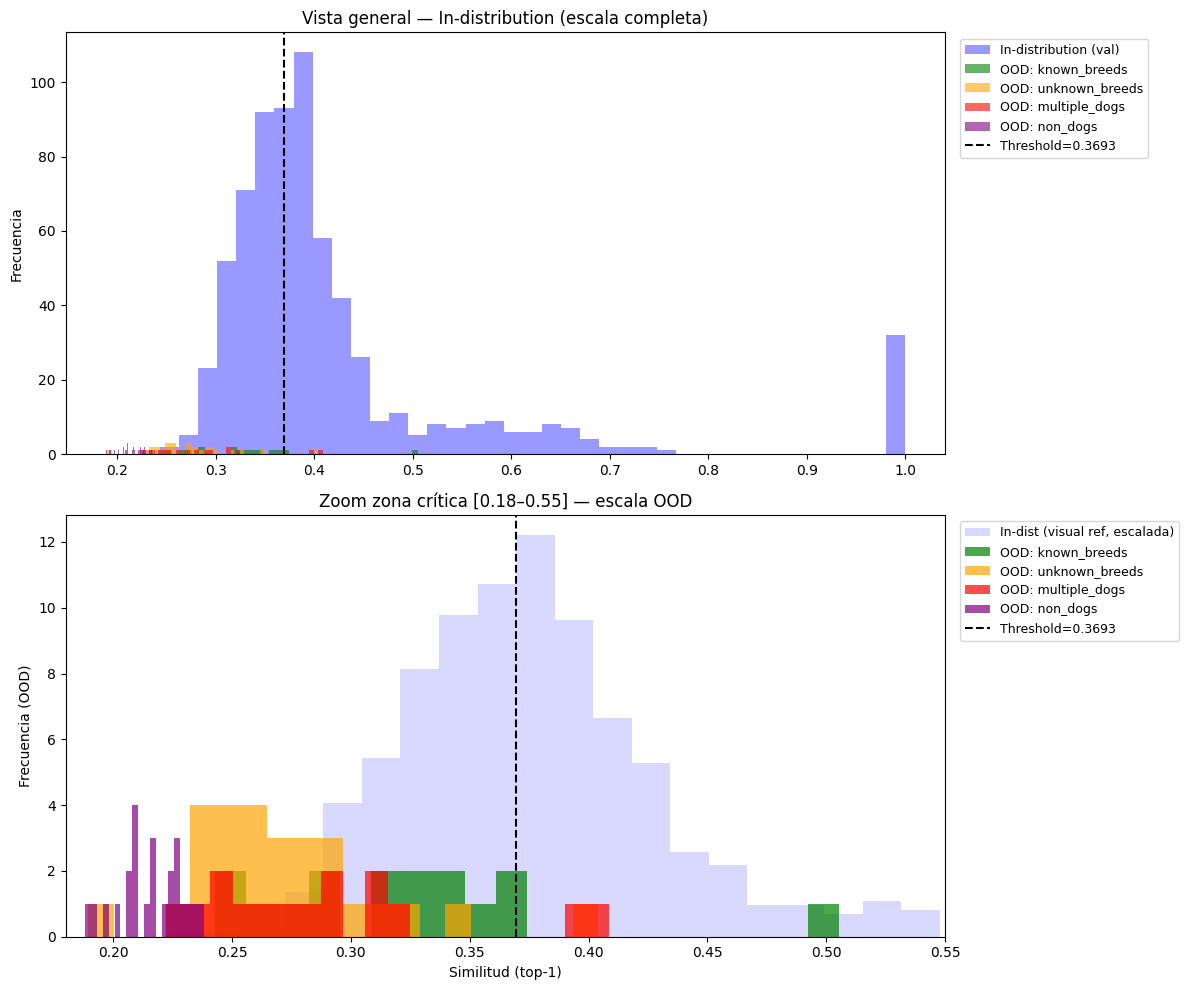

In [ ]:
scores_in = []
for entry, emb in zip(val_entries, val_embs):
    results = search_similar_images(emb, train_entries, train_embs, METRICA_FN, top_k=1)
    if results:
        scores_in.append(results[0]["similarity"])

# Scores OOD segmentados por categoría
scores_by_category = {cat: [] for cat in OOD_CONFIG.keys()}

for entry, emb in zip(ood_full_entries, ood_embs):
    results = search_similar_images(emb, train_entries, train_embs, METRICA_FN, top_k=1)
    if results:
        scores_by_category[entry["category"]].append(results[0]["similarity"])

scores_out = [s for sublist in scores_by_category.values() for s in sublist]

# ROC
labels = [1] * len(scores_in) + [0] * len(scores_out)
scores = scores_in + scores_out

fpr, tpr, thresholds = roc_curve(labels, scores)
auc = roc_auc_score(labels, scores)

# Modificación: Mejor threshold basado en FPR fijo (ej. FPR <= 5%)
target_fpr = 0.05
# Encontrar el índice del umbral más alto que satisface el target_fpr
idx = np.where(fpr <= target_fpr)[0]
if len(idx) > 0:
    mejor_idx = idx[-1] # Tomar el último índice para el threshold más alto posible
    mejor_th = thresholds[mejor_idx]
else:
    mejor_th = thresholds[0] # Si no se encuentra, usar el primer umbral (más restrictivo)

# Métricas
print(f"AUC:              {auc:.4f}")
print(f"Mejor threshold:  {mejor_th:.4f}")
print(f"Percentil 5 val:  {np.percentile(scores_in, 5):.4f}")
print(f"Percentil 10 val: {np.percentile(scores_in, 10):.4f}")

# Visualización
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

# Vista general (in-distribution domina) 
ax1.hist(scores_in, bins=40, alpha=0.4, label="In-distribution (val)", color="blue")
for cat, scores in scores_by_category.items():
    ax1.hist(scores, bins=40, alpha=0.6, label=f"OOD: {cat}", color=colores.get(cat, "gray"))
ax1.axvline(mejor_th, color="black", linestyle="--", label=f"Threshold={mejor_th:.4f}")
ax1.set_title("Vista general — In-distribution (escala completa)")
ax1.set_ylabel("Frecuencia")
ax1.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)

# Zoom en zona crítica, eje Y escalado a OOD 
zoom_min, zoom_max = 0.18, 0.55
scores_in_zoom = [s for s in scores_in if zoom_min <= s <= zoom_max]

# Escala in-distribution para que sirva de referencia sin aplastar OOD
ood_all = [s for sub in scores_by_category.values() for s in sub if zoom_min <= s <= zoom_max]
scale_factor = max(len(ood_all) / len(scores_in_zoom), 0.05) if scores_in_zoom else 1

ax2.hist(scores_in_zoom, bins=20, alpha=0.15, color="blue",
         weights=[scale_factor]*len(scores_in_zoom), label="In-dist (visual ref, escalada)")
for cat, scores in scores_by_category.items():
    s_zoom = [s for s in scores if zoom_min <= s <= zoom_max]
    if s_zoom:
        ax2.hist(s_zoom, bins=20, alpha=0.7, label=f"OOD: {cat}", color=colores.get(cat, "gray"))
ax2.axvline(mejor_th, color="black", linestyle="--", label=f"Threshold={mejor_th:.4f}")
ax2.set_xlim(zoom_min, zoom_max)
ax2.set_title("Zoom zona crítica [0.18–0.55] — escala OOD")
ax2.set_xlabel("Similitud (top-1)")
ax2.set_ylabel("Frecuencia (OOD)")
ax2.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)

plt.tight_layout()
plt.show()

La Figura muestra la distribución de las similitudes obtenidas para las imágenes del conjunto de validación y para las distintas categorías de consultas OOD. En el gráfico superior se observa la distribución completa de las similitudes, mientras que el inferior amplía la región donde ambas distribuciones presentan mayor solapamiento, facilitando el análisis del punto de separación.

Puede observarse que las consultas pertenecientes a la distribución conocida tienden a concentrar valores de similitud superiores, mientras que las imágenes OOD presentan, en general, similitudes considerablemente menores. Sin embargo, existe una región de transición donde ambas distribuciones se superponen parcialmente, haciendo imposible una separación perfecta mediante un único umbral.

El valor seleccionado (**threshold = 0.3693**) representa un compromiso entre aceptar la mayor cantidad posible de consultas válidas y rechazar correctamente las imágenes fuera de distribución. Umbrales más elevados incrementarían la precisión de las consultas aceptadas, pero reducirían la cobertura del sistema al descartar imágenes válidas. Por el contrario, umbrales más bajos aumentarían la cobertura, aunque permitirían aceptar un mayor número de consultas OOD. Este equilibrio resulta fundamental para garantizar un comportamiento robusto en escenarios reales.


### Optimización del número de vecinos (K)

Una vez determinado el umbral de aceptación, se optimizó el número de vecinos **K** utilizado durante la clasificación. Para ello se evaluaron distintos valores de K sobre el conjunto de validación considerando dos criterios complementarios.

Por un lado, se midió la Accuracy, que refleja la capacidad del sistema para predecir correctamente la raza mediante el voto mayoritario ponderado de los vecinos recuperados. Por otro, se analizó el NDCG, métrica que evalúa exclusivamente la calidad del ranking de recuperación generado por la búsqueda por similitud. Mientras la Accuracy depende del mecanismo de votación y, por lo tanto, del valor de K, el NDCG cuantifica qué tan bien ordenadas aparecen las imágenes relevantes dentro de los primeros resultados.

K elegido (mejor NDCG): 7


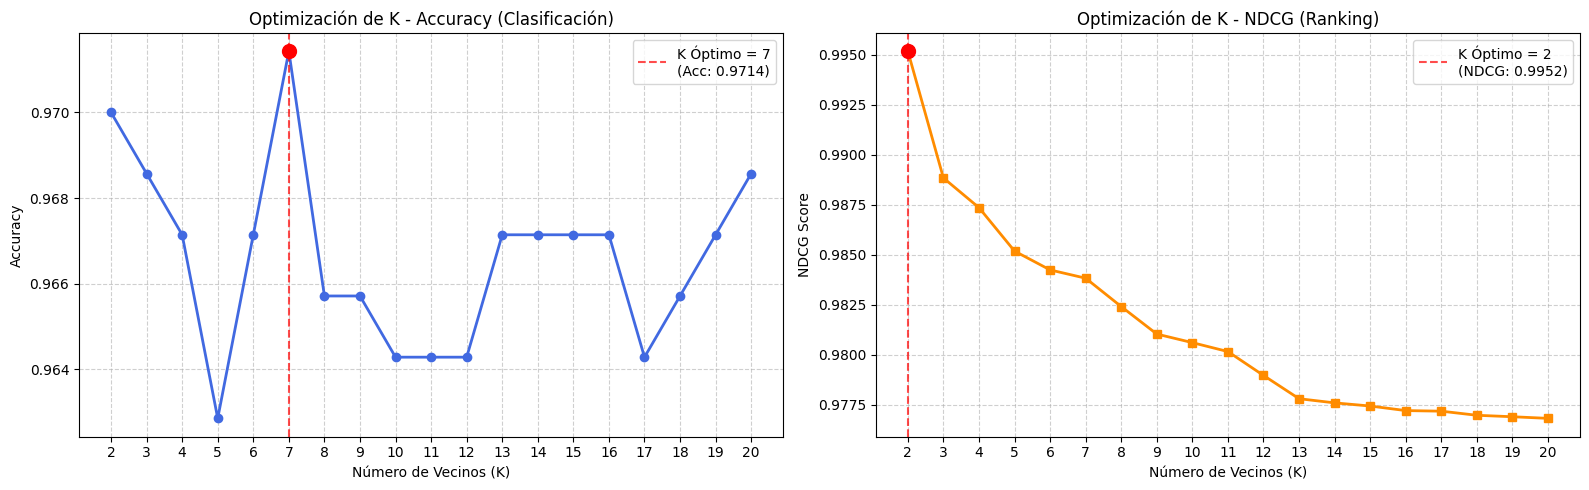

In [82]:
valores_k = [x for x in range(2, 21)]
historial_acc = []
historial_ndcg = []

for k in valores_k:
    metricas = evaluar_modelo(val_entries, val_embs, index_entries=train_entries, index_embs=train_embs, similarity_fn=METRICA_FN, top_k=k)
    acc = metricas["accuracy"]
    ndcg = metricas["ndcg@10"]
    historial_acc.append(acc)
    historial_ndcg.append(ndcg)

# K elegido por mejor NDCG
mejor_k = valores_k[np.argmax(historial_acc)]
print(f"K elegido (mejor NDCG): {mejor_k}")

graficar_k(valores_k, historial_acc, historial_ndcg)

Los resultados muestran comportamientos diferentes para ambas métricas. La Accuracy alcanza su valor máximo con **K = 7** (0.9714), indicando que considerar siete vecinos proporciona el mejor equilibrio para la clasificación mediante voto ponderado. Utilizar menos vecinos hace que la predicción dependa excesivamente de coincidencias individuales, mientras que valores mayores comienzan a incorporar vecinos menos representativos, reduciendo ligeramente el desempeño.

En contraste, el NDCG obtiene su máximo con **K = 2** y disminuye gradualmente a medida que aumenta el número de vecinos considerados. Este comportamiento es esperable, ya que el NDCG evalúa la calidad del ranking generado por la búsqueda y favorece configuraciones donde los primeros resultados concentran la mayor relevancia posible. Al extender el ranking hacia vecinos más lejanos, la ganancia acumulada disminuye progresivamente.

Dado que el objetivo final del sistema es **clasificar correctamente la raza** de las consultas aceptadas, se priorizó la Accuracy como criterio para la selección de este hiperparámetro. En consecuencia, se adoptó **K = 7** como configuración definitiva para las etapas posteriores, manteniendo un ranking de alta calidad (NDCG cercano a 0.98) y maximizando simultáneamente el desempeño de clasificación.


## 11. Resultados finales

### Visualización de los embeddings mediante t-SNE

Con el objetivo de analizar cualitativamente la calidad de las representaciones aprendidas por el modelo seleccionado, se proyectaron los embeddings de alta dimensión sobre un espacio bidimensional mediante **t-SNE**. Esta técnica de reducción de dimensionalidad preserva, en la medida de lo posible, las relaciones de vecindad entre muestras, permitiendo visualizar cómo se agrupan las imágenes según las características extraídas por el backbone.


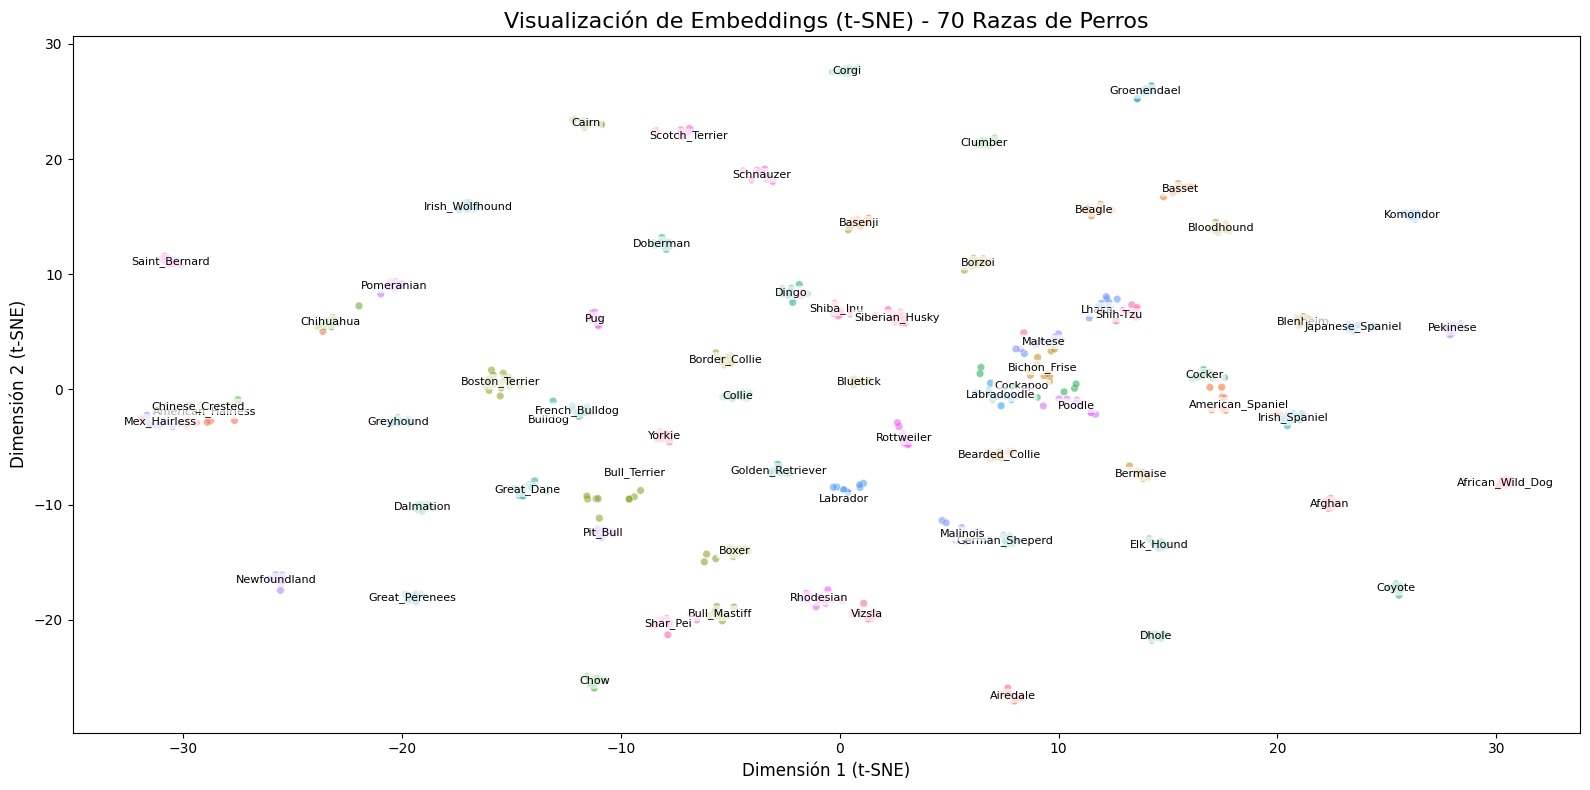

In [51]:
if MODELO_ELEGIDO in emb_cache and "test" in emb_cache[MODELO_ELEGIDO]:
    test_embs_final = emb_cache[MODELO_ELEGIDO]["test"]
else:
    test_embs_final = [np.array(extract_embedding(e["path"], model_elegido)) for e in test_entries]
    if MODELO_ELEGIDO not in emb_cache: emb_cache[MODELO_ELEGIDO] = {}
    emb_cache[MODELO_ELEGIDO]["test"] = test_embs_final

test_embs = test_embs_final
graficar_tsne(test_embs, y_test_labels)

La proyección obtenida evidencia que los embeddings generados por **ConvNeXt Tiny** presentan una estructura discriminativa consistente. En la mayoría de las razas, las imágenes correspondientes se agrupan formando clústeres compactos, indicando que el modelo logra extraer representaciones similares para ejemplares de una misma categoría.

Asimismo, puede observarse que razas con características morfológicas similares tienden a ubicarse relativamente próximas entre sí, mientras que aquellas con rasgos visuales claramente diferenciados aparecen separadas en el espacio proyectado. Esta organización constituye un indicio de que el espacio de embeddings preserva adecuadamente las relaciones semánticas necesarias para realizar búsquedas por similitud.

Si bien existen algunos grupos parcialmente solapados —un comportamiento esperable debido a las similitudes visuales entre determinadas razas y a la reducción de dimensionalidad realizada por t-SNE—, la separación global observada resulta consistente con el elevado desempeño obtenido posteriormente en las métricas de recuperación.


### Ejemplos de recuperación por similitud

Una vez validada la estructura del espacio de embeddings, resulta conveniente analizar el comportamiento del sistema desde una perspectiva cualitativa. Para ello se presentan un ejemplo, donde a partir de una imagen de entrada, el sistema recupera las **10 imágenes más similares** almacenadas en el índice vectorial.

Esta visualización permite verificar que la búsqueda basada en vecinos más cercanos no solo obtiene buenos resultados desde el punto de vista de las métricas, sino que también recupera imágenes visualmente coherentes con la consulta.

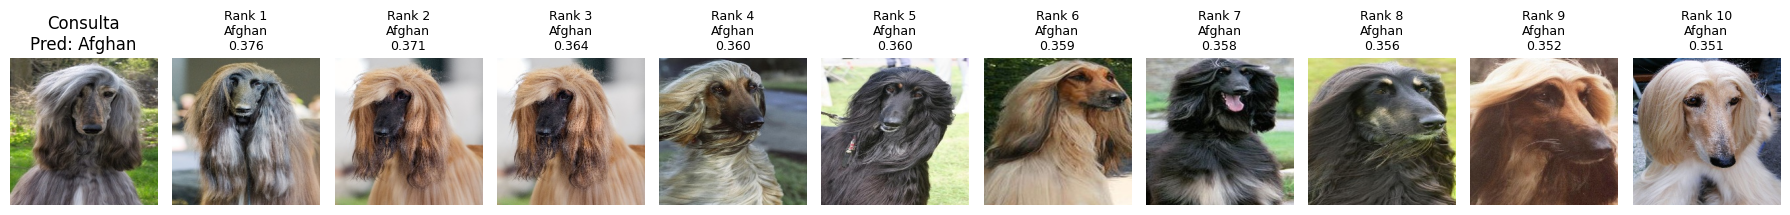

In [71]:
visualizar_top_k_real(0, test_entries, test_embs, train_entries, train_embs, METRICA_FN, k=10)

En los ejemplos presentados puede observarse que las imágenes recuperadas corresponden exactamente a la misma raza que la imagen de consulta, logrando mantener esas características visuales como la morfología, la textura del pelaje, la postura y la perspectiva en los embeddings.



### Evaluación final sobre el conjunto de prueba

Finalmente, una vez fijados el backbone, la métrica de similitud, el umbral de aceptación y el número de vecinos, se evaluó el sistema completo sobre el conjunto **Test**, el cual permaneció completamente aislado durante todas las etapas de selección y optimización de hiperparámetros.


In [83]:
resultado_final = evaluar_con_threshold(test_entries, test_embs, METRICA_FN, top_k=mejor_k, threshold=mejor_th)
metricas_ranking = evaluar_modelo(test_entries, test_embs, train_entries, train_embs, METRICA_FN, top_k=10)
ndcg_val = metricas_ranking['ndcg@10']

print("=" * 40)
print("   Evaluación final — Test")
print("=" * 40)
print(f"   Accuracy global:          {resultado_final['accuracy_global']:.4f}")
print(f"   Accuracy sobre aceptadas: {resultado_final['accuracy_sobre_aceptadas']:.4f}")
print(f"   NDCG@10:                  {ndcg_val:.4f}") 
print(f"   Cobertura:                {resultado_final['cobertura']:.4f}")
print(f"   Aceptadas:                {resultado_final['aceptadas']}")
print(f"   Rechazadas:               {resultado_final['rechazadas']}")
print("=" * 40)

   Evaluación final — Test
   Accuracy global:          0.2629
   Accuracy sobre aceptadas: 0.9787
   NDCG@10:                  0.9774
   Cobertura:                0.2686
   Aceptadas:                188
   Rechazadas:               512


Los resultados muestran una **Accuracy sobre consultas aceptadas del 97.87%**, indicando que, cuando el sistema considera que una consulta pertenece a la distribución conocida, la predicción de la raza resulta altamente confiable. Este comportamiento se complementa con un **NDCG@10 de 0.9774**, valor que confirma que las imágenes relevantes aparecen correctamente posicionadas entre los primeros resultados del ranking de recuperación.

Por otra parte, la **cobertura del 26.86%** indica que únicamente una fracción de las consultas supera el umbral de aceptación establecido. En consecuencia, la **Accuracy global** se reduce al 26.29%, ya que las consultas rechazadas se contabilizan como predicciones incorrectas. Este resultado no constituye una limitación del modelo de embeddings, sino una consecuencia directa de haber priorizado un criterio de aceptación conservador durante la optimización del *threshold*.

En conjunto, estas métricas reflejan el compromiso asumido entre cobertura y confiabilidad. El modelo realiza predicciones únicamente cuando existe suficiente evidencia de similitud, minimizando así el riesgo de asignar una raza incorrecta a imágenes ambiguas o fuera de distribución. 


## 12 Conclusión

En esta primera etapa se desarrolló un sistema completo de búsqueda por similitud de imágenes basado en **embeddings** generados mediante modelos preentrenados. 

La comparación entre modelos evidenció que la calidad de los embeddings depende principalmente de la arquitectura utilizada. En particular, **ConvNeXt Tiny** obtuvo el mejor desempeño en términos de NDCG@10, demostrando una mayor capacidad para generar representaciones discriminativas que preservan la similitud semántica entre imágenes de una misma raza. Asimismo, se observó que la elección de la métrica de distancia (Coseno o L2) tiene una influencia significativamente menor sobre el rendimiento. Cabe destacar que **los embeddings no fueron normalizados** antes de la comparación, decisión tomada deliberadamente para evaluar ambas métricas bajo condiciones donde pudieran producir rankings diferentes. De haberse normalizado los vectores a norma unitaria, la distancia Euclídea y la similitud por Coseno habrían generado ordenamientos prácticamente equivalentes, haciendo poco informativa su comparación. En este contexto, la distancia Euclídea (L2) obtuvo el mejor desempeño para el modelo seleccionado.

Posteriormente, la incorporación de consultas **Out-of-Distribution (OOD)** permitió definir un umbral de aceptación que dota al sistema de un mecanismo de rechazo frente a imágenes ambiguas o pertenecientes a clases no contempladas. Esta estrategia introduce un compromiso entre cobertura y confiabilidad: un umbral más estricto reduce la cantidad de consultas aceptadas, pero incrementa considerablemente la precisión de las predicciones emitidas. De manera complementaria, la optimización del número de vecinos permitió seleccionar la configuración que maximiza el desempeño del proceso de clasificación sin comprometer la calidad del ranking de recuperación.

Los análisis cualitativos, tanto mediante la visualización de los embeddings con t-SNE como a través de ejemplos de recuperación por similitud, corroboran los resultados obtenidos cuantitativamente. Los embeddings presentan una estructura coherente, agrupando imágenes de una misma raza y permitiendo recuperar vecinos visualmente consistentes, lo que demuestra que el espacio de representación aprendido captura adecuadamente las características discriminativas del problema.

En conjunto, los resultados obtenidos validan la efectividad del enfoque propuesto para la búsqueda por similitud de razas de perros. La evaluación comparativa de arquitecturas, la optimización del umbral de aceptación y la selección del número de vecinos permitieron definir una configuración que combina una alta calidad de recuperación con un mecanismo robusto de rechazo para consultas fuera de distribución. Como resultado de este proceso, **ConvNeXt Tiny**, utilizando la **distancia Euclídea (L2)**, fue seleccionado como el modelo base para el sistema en producción, constituyendo la representación visual definitiva sobre la cual se realizarán las consultas de similitud y la indexación del conjunto completo de imágenes en la base vectorial.


## 13. Indexación del dataset en la base vectorial

Ahora que elegimos el modelo, indexamos **todo** el dataset (train + valid + test)
usando los scripts provistos por la cátedra.

In [ ]:
#!python scripts/build_index.py --split train
#!python scripts/build_index.py --split valid
#!python scripts/build_index.py --split test